In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/sample_submission.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/train_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/test_dataset.csv
/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/val_dataset.csv


In [2]:
import os
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, confusion_matrix
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from collections import Counter

In [3]:
source_dir = "/kaggle/input/ai-2-deep-learning-for-nlp-homework-1/"
testData = pd.read_csv(os.path.join(source_dir, "test_dataset.csv"))
trainData = pd.read_csv(os.path.join(source_dir, "train_dataset.csv"))
validationData = pd.read_csv(os.path.join(source_dir, "val_dataset.csv"))

In [4]:
def text_preprocessing(text):
  text = text.lower()
  text = re.sub(r'\s+', ' ', text).strip()
  text = re.sub(r'http\S+', '', text)
  text = re.sub(r'www\S+', '', text)
  text = re.sub(r'pic.\S+', '', text)
  text = re.sub(r'\babt\b', 'about', text)
  text = re.sub(r'\band\b', 'and', text)
  text = re.sub(r'\bb4\b', 'before', text)
  text = re.sub(r'\bbrb\b', 'be right back', text)
  text = re.sub(r'\bbtw\b', 'but the way', text)
  text = re.sub(r'\bgr8\b', 'great', text)
  text = re.sub(r'\bgud\b', 'good', text)
  text = re.sub(r'\bgn\b', 'good night', text)
  text = re.sub(r'\bh8\b', 'hate', text)
  text = re.sub(r'\bhavent\b', "have not", text)
  text = re.sub(r'\bhavnt\b', "have not", text)
  text = re.sub(r'\bhav\b', 'have', text)
  text = re.sub(r'\bidk\b', "i do not know", text)
  text = re.sub(r'\b2moro\b', 'tomorrow', text)
  text = re.sub(r'\b2nite\b', 'tonight', text)
  text = re.sub(r'\bcant\b', "can not", text)
  text = re.sub(r'\bcnt\b', "can not", text)
  text = re.sub(r'\bcuz\b', 'because', text)
  text = re.sub(r'\bfreind\b', 'friend', text)
  text = re.sub(r'\bfyi\b', 'for your information', text)
  text = re.sub(r'\bgr8\b', 'great', text)
  text = re.sub(r'\bskool\b', 'school', text)
  text = re.sub(r'\bl8r\b', 'later', text)
  text = re.sub(r'\bm8\b', 'mate', text)
  text = re.sub(r'\bmabe\b', 'maybe', text)
  text = re.sub(r'\bn0\b', 'no one', text)
  text = re.sub(r'\bno1\b', 'no one', text)
  text = re.sub(r'\bplz\b', 'please', text)
  text = re.sub(r'\bpls\b', 'please', text)
  text = re.sub(r'\bta\b', 'thanks', text)
  text = re.sub(r'\bthanx\b', 'thanks', text)
  text = re.sub(r'\bteh\b', 'the', text)
  text = re.sub(r'\bthx\b', 'thanks', text)
  text = re.sub(r'\bthier\b', 'their', text)
  text = re.sub(r'\bwut\b', 'what', text)
  text = re.sub(r'\bwould\b', 'would', text)
  text = re.sub(r'\bwierd\b', 'weird', text)
  text = re.sub(r'\bskool\b', 'school', text)
  text = re.sub(r'(?<!\w)u(?!\w)', 'you', text)
  text = re.sub(r'\br\b', 'are', text)
  text = re.sub(r'(?<!\w)y(?!\w)', 'why', text)
  text = re.sub(r'\bthats\b', 'that is', text)
  text = re.sub(r'\bthatis\b', 'that is', text)
  text = re.sub(r'\bcya\b', 'see you', text)
  text = re.sub(r'\bwasnt\b', "was not", text)
  text = re.sub(r'\bkno\b', 'know', text)
  text = re.sub(r'\bur\b', 'you are', text)
  text = re.sub(r'&[^;]+;', '', text)
  text = re.sub(r"'s", ' is', text)
  text = re.sub(r'@\w+', '', text)
  text = re.sub(r"n't", ' not', text)
  text = re.sub(r"'re", ' are', text)
  text = re.sub(r"'ll", ' will', text)
  text = re.sub(r"'m", ' am', text)

  return text


trainData['Text'] = trainData['Text'].apply(text_preprocessing)
validationData['Text'] = validationData['Text'].apply(text_preprocessing)
testData['Text'] = testData['Text'].apply(text_preprocessing)

In [5]:
# from nltk.tokenize import word_tokenize
# from nltk.stem import WordNetLemmatizer
# # Ensure you have required NLTK resources
# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('punkt_tab')
# nltk.download('wordnet')

# lemmatizer = WordNetLemmatizer()

# def tokenize_text(text):
#     return word_tokenize(text)

# def lemmatize_tokens(tokens):
#     return [lemmatizer.lemmatize(token) for token in tokens]

# trainData['Text_Preprocessed'] = trainData['Text'].apply(text_preprocessing)
# validationData['Text_Preprocessed'] = validationData['Text'].apply(text_preprocessing)

# trainData['Tokenized'] = trainData['Text_Preprocessed'].apply(tokenize_text)
# validationData['Tokenized'] = validationData['Text_Preprocessed'].apply(tokenize_text)

# trainData['Lemmatized'] = trainData['Tokenized'].apply(lemmatize_tokens)
# validationData['Lemmatized'] = validationData['Tokenized'].apply(lemmatize_tokens)

# trainData['Text_Joined'] = trainData['Lemmatized'].apply(lambda x: ' '.join(x))
# validationData['Text_Joined'] = validationData['Lemmatized'].apply(lambda x: ' '.join(x))

In [6]:
# def text_preprocessing_stopwords(text):
#   stopwords = stopwords_list.words('english')
#   text = ' '.join([word for word in text.split() if word not in stopwords])
#   return text

# trainData['Text'] = trainData['Text'].apply(text_preprocessing_stopwords)
# validationData['Text'] = validationData['Text'].apply(text_preprocessing_stopwords)

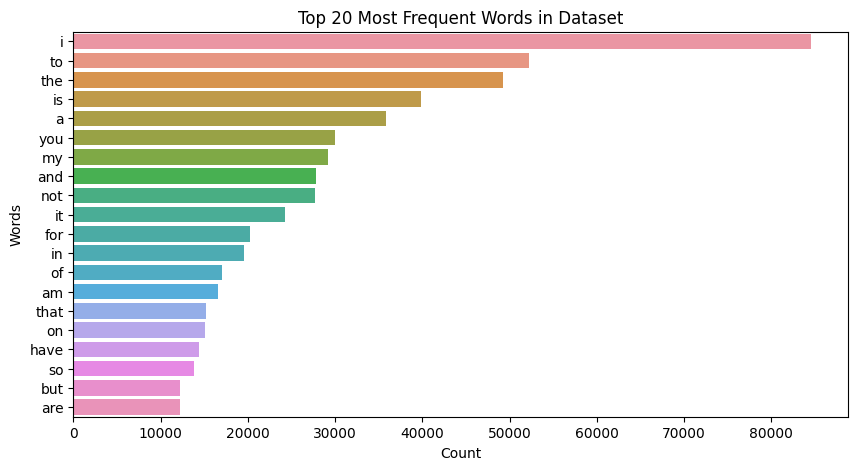

Fitting 10 folds for each of 1 candidates, totalling 10 fits

Best parameters: {'classifier__C': 1.1, 'classifier__max_iter': 200, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs', 'tfidf__max_df': 0.2, 'tfidf__max_features': 100000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3), 'tfidf__norm': 'l2'}
Best cross-validation score: 0.8007

Test set accuracy: 0.8044
Precision: 0.8044
Recall: 0.8101
F1 Score: 0.8055

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80     21197
           1       0.80      0.81      0.81     21199

    accuracy                           0.80     42396
   macro avg       0.80      0.80      0.80     42396
weighted avg       0.80      0.80      0.80     42396



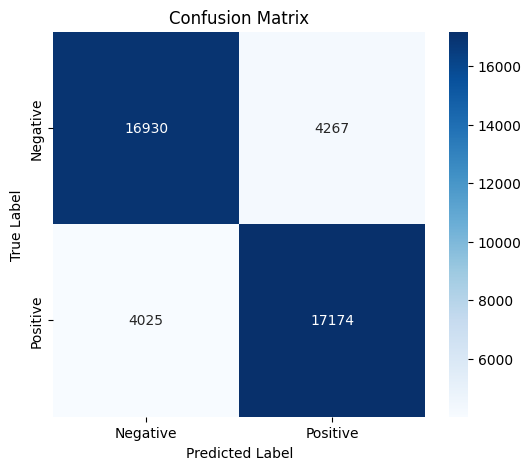

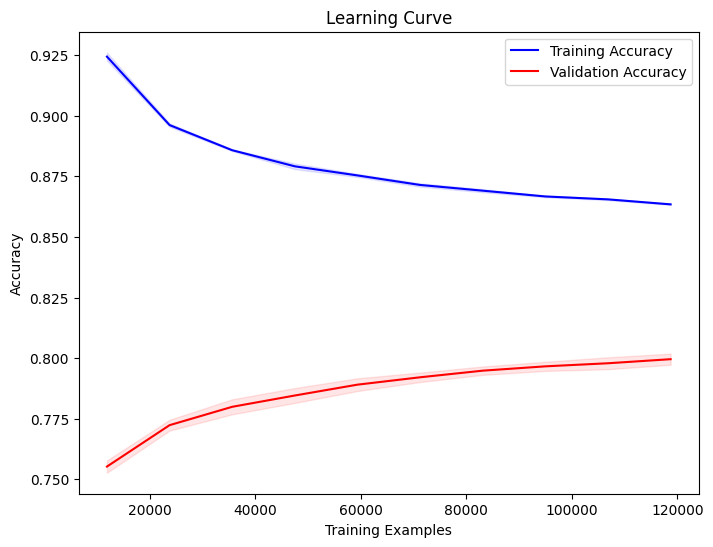

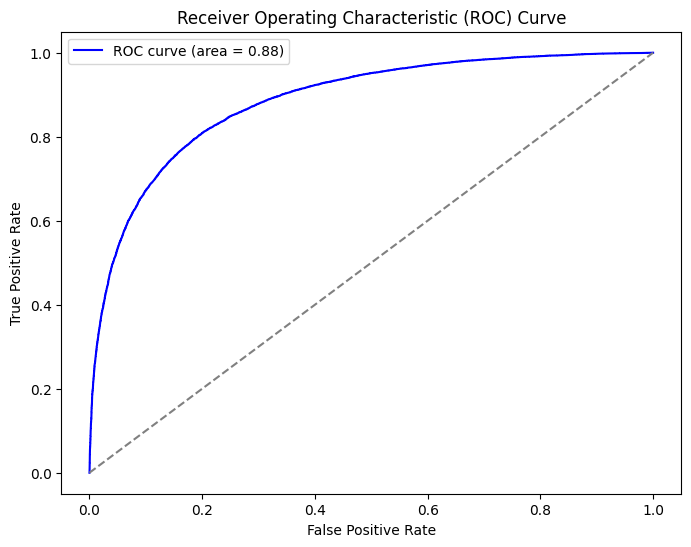

In [7]:
# X_train_dataset, X_test_dataset, Y_train_dataset, Y_test_dataset = train_test_split(trainData['Text'],trainData['Label'])
X_test_dataset = validationData['Text']
Y_test_dataset = validationData['Label']
X_train_dataset = trainData['Text']
Y_train_dataset = trainData['Label']

word_counter = Counter(" ".join(X_train_dataset).split())

most_common_words = word_counter.most_common(20)

common_words_df = pd.DataFrame(most_common_words, columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 5))
sns.barplot(x='Frequency', y='Word', data=common_words_df)
plt.xlabel("Count")
plt.ylabel("Words")
plt.title("Top 20 Most Frequent Words in Dataset")
plt.show()

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('classifier', LogisticRegression(random_state=42))
])

param_grid = {
    'tfidf__ngram_range': [(1,3)],  
    'tfidf__max_df': [0.2],                
    'tfidf__min_df': [1],                      
    'tfidf__max_features': [100000],    
    'tfidf__norm': ['l2'],                     

    'classifier__C': [1.1],               
    'classifier__solver': ['lbfgs'],
    'classifier__max_iter': [200],
    'classifier__penalty': ['l2']
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=10,                  
    scoring='accuracy',    # Metric to optimize
    verbose=2,             # Print progress
    n_jobs=-1              # Use all available cores
)

grid_search.fit(X_train_dataset, Y_train_dataset)

print("\nBest parameters:", grid_search.best_params_)
print("Best cross-validation score: {:.4f}".format(grid_search.best_score_))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_dataset)
print("\nTest set accuracy: {:.4f}".format(accuracy_score(Y_test_dataset, y_pred)))
print("Precision: {:.4f}".format(accuracy_score(Y_test_dataset, y_pred)))
print("Recall: {:.4f}".format(recall_score(Y_test_dataset, y_pred)))
print("F1 Score: {:.4f}".format(f1_score(Y_test_dataset, y_pred)))
print("\nClassification Report:")
print(classification_report(Y_test_dataset, y_pred))

cm = confusion_matrix(Y_test_dataset, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

train_sizes, train_scores, test_scores = learning_curve(best_model, X_train_dataset, Y_train_dataset, train_sizes=np.linspace(0.1, 1.0, 10))

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Training Accuracy', color='blue')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.plot(train_sizes, test_mean, label='Validation Accuracy', color='red')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='red')

plt.xlabel('Training Examples')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

y_probs = best_model.predict_proba(X_test_dataset)[:, 1]  # Get probabilities for class 1

fpr, tpr, _ = roc_curve(Y_test_dataset, y_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')  # Diagonal line (random guessing)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

In [8]:
test_predictions = best_model.predict(testData['Text'])

id_column = None
for column in testData.columns:
    if column.lower() == 'id':
        id_column = column
        break

if id_column:
    submission = pd.DataFrame({
        'ID': testData[id_column],
        'Label': test_predictions
    })
else:
    print("Test dataset columns:", testData.columns.tolist())
    
    submission = pd.DataFrame({
        'ID': range(len(test_predictions)), 
        'Label': test_predictions
    })

submission.to_csv('submission.csv', index=False)